# Task 1: Exploratory Data Analysis (EDA) on the Superstore Sales Dataset

**Objective:** Perform industry-style Exploratory Data Analysis on a real sales dataset, covering
data cleaning, missing-value analysis, descriptive statistics, outlier checks, correlation analysis
and informative visualizations, then summarize the main business findings.

**Dataset:** Superstore Sales, 8,399 order records with 21 columns covering order details,
customer details, product details, sales, discount and profit.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

The dataset is stored in `data/sales_data.csv`. Each row is one product line inside a customer
order, so a single `Order ID` can appear more than once.

In [2]:
df = pd.read_csv("data/sales_data.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head()

Rows: 8399
Columns: 21


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


## 3. Basic Data Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8399 entries, 0 to 8398
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Row ID                8399 non-null   int64  
 1   Order ID              8399 non-null   int64  
 2   Order Date            8399 non-null   str    
 3   Order Priority        8399 non-null   str    
 4   Order Quantity        8399 non-null   int64  
 5   Sales                 8399 non-null   float64
 6   Discount              8399 non-null   float64
 7   Ship Mode             8399 non-null   str    
 8   Profit                8399 non-null   float64
 9   Unit Price            8399 non-null   float64
 10  Shipping Cost         8399 non-null   float64
 11  Customer Name         8399 non-null   str    
 12  Province              8399 non-null   str    
 13  Region                8399 non-null   str    
 14  Customer Segment      8399 non-null   str    
 15  Product Category      8399 non-n

In [4]:
print("Column names:")
for col in df.columns:
    print(" -", col)

Column names:
 - Row ID
 - Order ID
 - Order Date
 - Order Priority
 - Order Quantity
 - Sales
 - Discount
 - Ship Mode
 - Profit
 - Unit Price
 - Shipping Cost
 - Customer Name
 - Province
 - Region
 - Customer Segment
 - Product Category
 - Product Sub-Category
 - Product Name
 - Product Container
 - Product Base Margin
 - Ship Date


In [5]:
print("Duplicate rows:", df.duplicated().sum())
print("Unique orders:", df["Order ID"].nunique())
print("Unique customers:", df["Customer Name"].nunique())
print("Unique products:", df["Product Name"].nunique())

Duplicate rows: 0
Unique orders: 5496
Unique customers: 795
Unique products: 1263


### Observations
- The dataset has **8,399 rows and 21 columns**: 8 numeric columns and 13 text/date columns.
- There are **no fully duplicated rows**.
- The 8,399 rows belong to a smaller number of unique orders, which confirms that each row is a
  product line inside an order, not a whole order.
- `Order Date` and `Ship Date` were loaded as plain text, so they need to be converted to real
  date types before any time-based analysis.

## 4. Data Cleaning

Three cleaning steps are needed here:
1. Convert `Order Date` and `Ship Date` to proper datetime values.
2. Standardize column names so they are easier to work with in code.
3. Create a `Shipping Delay` column (days between order and shipment), which is useful later.

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days

print("Order Date range:", df["Order Date"].min().date(), "to", df["Order Date"].max().date())
print("Shipping delay range:", df["Shipping Delay"].min(), "to", df["Shipping Delay"].max(), "days")
df[["Order Date", "Ship Date", "Shipping Delay"]].head()

Order Date range: 2009-01-01 to 2012-12-30
Shipping delay range: 0 to 92 days


,Order Date,Ship Date,Shipping Delay
0,2010-10-13,2010-10-20,7
1,2012-10-01,2012-10-02,1
2,2012-10-01,2012-10-03,2
3,2011-07-10,2011-07-12,2
4,2010-08-28,2010-08-30,2


In [7]:
# Check for invalid records: negative shipping delay or non-positive sales
print("Orders shipped before they were placed:", (df["Shipping Delay"] < 0).sum())
print("Rows with Sales <= 0:", (df["Sales"] <= 0).sum())
print("Rows with Order Quantity <= 0:", (df["Order Quantity"] <= 0).sum())

Orders shipped before they were placed: 0
Rows with Sales <= 0: 0
Rows with Order Quantity <= 0: 0


### Observation
The dates convert cleanly and cover a four-year trading period. No order ships before it was
placed, and there are no zero or negative sales or quantities, so no rows need to be dropped for
being invalid.

## 5. Missing Value Analysis

Missing values are counted per column, both as a raw count and as a percentage of the dataset.

In [8]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing Count", ascending=False)
missing

,Missing Count,Missing %
Product Base Margin,63,0.75


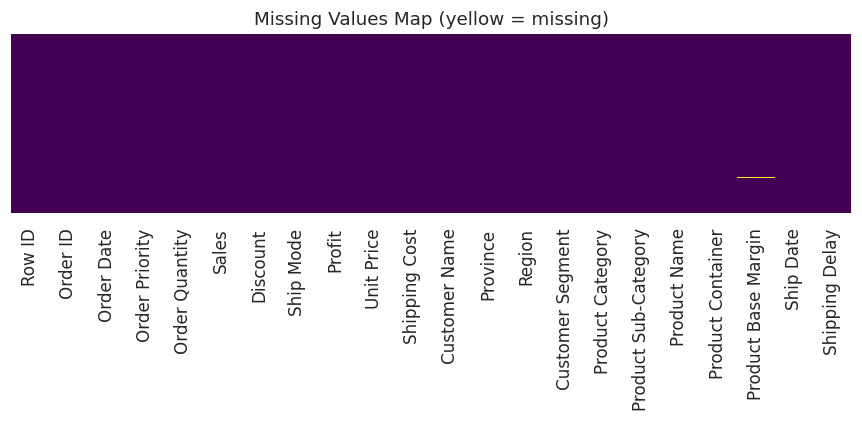

In [9]:
plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Map (yellow = missing)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("screenshots/01_missing_values_map.png", bbox_inches="tight")
plt.show()

In [10]:
# Product Base Margin is the only column with gaps. Fill with the median of its product category,
# which is safer than a single global median.
before = df["Product Base Margin"].isnull().sum()

df["Product Base Margin"] = df.groupby("Product Category")["Product Base Margin"].transform(
    lambda s: s.fillna(s.median())
)

after = df["Product Base Margin"].isnull().sum()
print("Missing before:", before)
print("Missing after :", after)
print("Total missing values left in dataset:", df.isnull().sum().sum())

Missing before: 63
Missing after : 0
Total missing values left in dataset: 0


### Observation
- Only **one column has missing data: `Product Base Margin`, with 63 missing values (0.75%)**.
- Because the gap is small and the column is numeric, the rows are kept and the gaps are filled
  with the **median margin of the same product category**. Dropping 63 rows would also have worked,
  but filling keeps every sale in the analysis.
- After this step the dataset has **zero missing values**.

## 6. Descriptive Statistics

In [11]:
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Row ID,8399.0,4200.0,1.0,2100.5,4200.0,6299.5,8399.0,2424.726789
Order ID,8399.0,29965.179783,3.0,15011.5,29857.0,44596.0,59973.0,17260.883447
Order Date,8399,2010-12-25 00:40:58.578402,2009-01-01 00:00:00,2009-12-20 00:00:00,2010-12-17 00:00:00,2012-01-01 12:00:00,2012-12-30 00:00:00,NaN
Order Quantity,8399.0,25.571735,1.0,13.0,26.0,38.0,50.0,14.481071
Sales,8399.0,1775.878179,2.24,143.195,449.42,1709.32,89061.05,3585.050525
Discount,8399.0,0.049671,0.0,0.02,0.05,0.08,0.25,0.031823
Profit,8399.0,181.184424,-14140.7,-83.315,-1.5,162.75,27220.69,1196.653371
Unit Price,8399.0,89.346259,0.99,6.48,20.99,85.99,6783.02,290.354383
Shipping Cost,8399.0,12.838557,0.49,3.3,6.07,13.99,164.73,17.264052
Product Base Margin,8399.0,0.512644,0.35,0.38,0.52,0.59,0.85,0.13536


In [12]:
cat_cols = ["Order Priority", "Ship Mode", "Region", "Customer Segment",
            "Product Category", "Product Container"]

for col in cat_cols:
    print(f"--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts())
    print()

--- Order Priority (5 unique) ---
Order Priority
High             1768
Low              1720
Not Specified    1672
Medium           1631
Critical         1608
Name: count, dtype: int64

--- Ship Mode (3 unique) ---
Ship Mode
Regular Air       6270
Delivery Truck    1146
Express Air        983
Name: count, dtype: int64

--- Region (8 unique) ---
Region
West                     1991
Ontario                  1826
Prarie                   1706
Atlantic                 1080
Quebec                    781
Yukon                     542
Northwest Territories     394
Nunavut                    79
Name: count, dtype: int64

--- Customer Segment (4 unique) ---
Customer Segment
Corporate         3076
Home Office       2032
Consumer          1649
Small Business    1642
Name: count, dtype: int64

--- Product Category (3 unique) ---
Product Category
Office Supplies    4610
Technology         2065
Furniture          1724
Name: count, dtype: int64

--- Product Container (7 unique) ---
Product Container


In [13]:
print("Total Sales   :", round(df["Sales"].sum(), 2))
print("Total Profit  :", round(df["Profit"].sum(), 2))
print("Average Sale  :", round(df["Sales"].mean(), 2))
print("Median Sale   :", round(df["Sales"].median(), 2))
print("Loss-making orders:", (df["Profit"] < 0).sum(),
      f"({(df['Profit'] < 0).mean() * 100:.1f}% of all rows)")

Total Sales   : 14915600.82
Total Profit  : 1521767.98
Average Sale  : 1775.88
Median Sale   : 449.42
Loss-making orders: 4264 (50.8% of all rows)


### Observation
- `Sales` is **heavily right-skewed**: the median sale is far below the mean, meaning most orders
  are small while a few very large orders pull the average up.
- `Profit` runs from large losses to large gains, and roughly **half of all order lines actually
  lose money**, which is the single most interesting business signal in this dataset.
- Office Supplies is the largest product category by row count, and the categorical columns are
  clean with no odd spellings or stray categories.

## 7. Outlier Detection

Outliers are checked with the **IQR rule**: any value below Q1 - 1.5xIQR or above Q3 + 1.5xIQR is
flagged.

In [14]:
num_cols = ["Sales", "Profit", "Order Quantity", "Unit Price",
            "Shipping Cost", "Discount", "Product Base Margin", "Shipping Delay"]

rows = []
for col in num_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n = ((df[col] < low) | (df[col] > high)).sum()
    rows.append([col, round(low, 2), round(high, 2), n, round(n / len(df) * 100, 2)])

outliers = pd.DataFrame(rows, columns=["Column", "Lower Bound", "Upper Bound",
                                       "Outlier Count", "Outlier %"])
outliers

,Column,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,Sales,-2205.99,4058.51,1042,12.41
1,Profit,-452.41,531.85,1704,20.29
2,Order Quantity,-24.50,75.50,0,0.00
3,Unit Price,-112.78,205.26,848,10.10
4,Shipping Cost,-12.74,30.03,972,11.57
5,Discount,-0.07,0.17,3,0.04
6,Product Base Margin,0.07,0.90,0,0.00
7,Shipping Delay,-0.50,3.50,1143,13.61


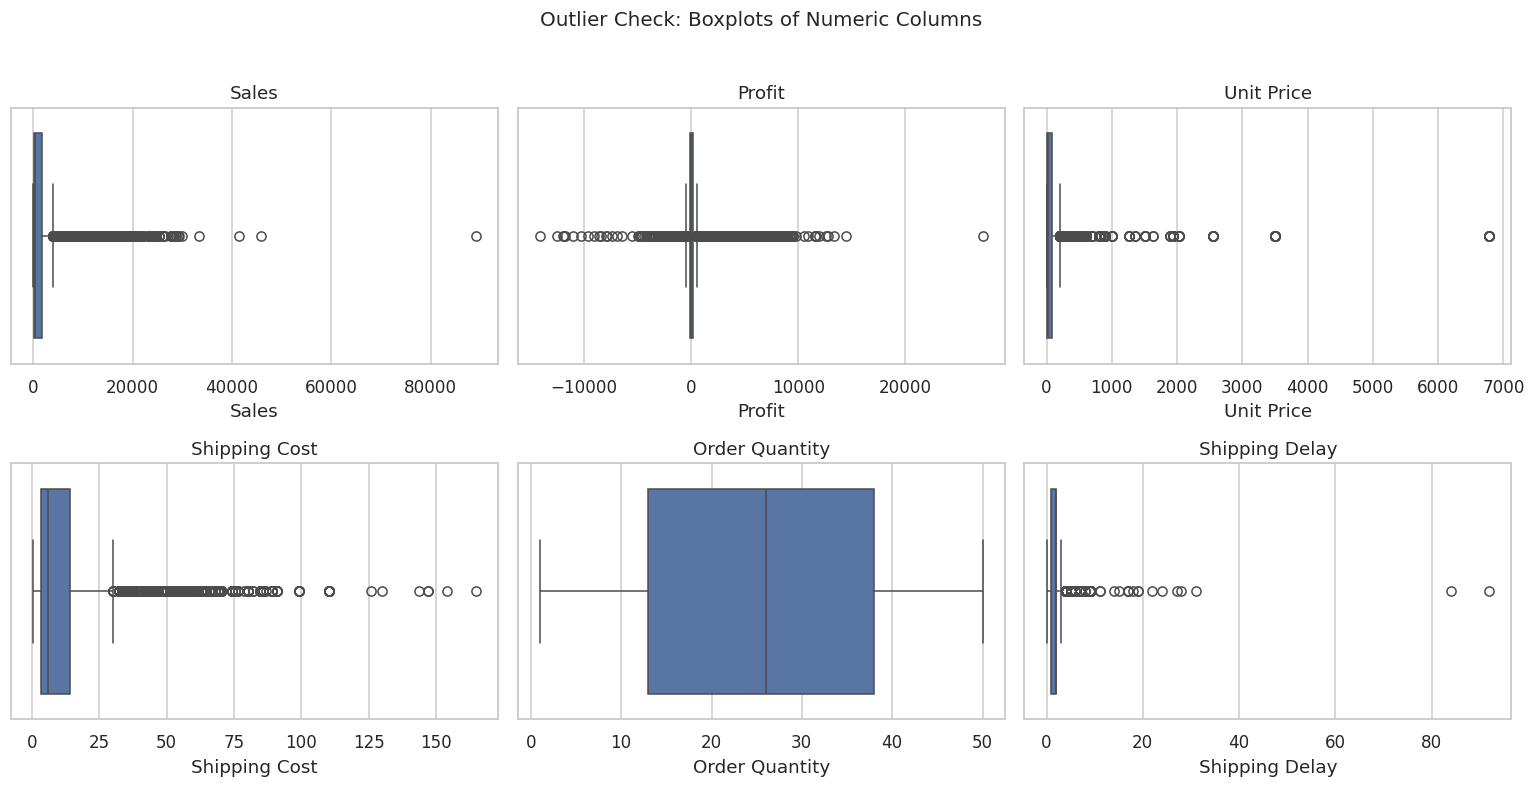

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flatten(), ["Sales", "Profit", "Unit Price",
                                    "Shipping Cost", "Order Quantity", "Shipping Delay"]):
    sns.boxplot(x=df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.suptitle("Outlier Check: Boxplots of Numeric Columns", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("screenshots/02_outlier_boxplots.png", bbox_inches="tight")
plt.show()

### Observation
- `Sales`, `Profit`, `Unit Price` and `Shipping Cost` all contain a **large number of statistical
  outliers**, which is normal for retail money columns.
- These are **kept, not removed**. A 10,000 dollar order or a 15,000 dollar loss is a genuine
  business event, not a data-entry error. Deleting them would hide exactly the transactions the
  business most needs to understand.
- `Order Quantity` and `Discount` are well behaved with few or no outliers.

## 8. Univariate Analysis: Distribution of Sales and Profit

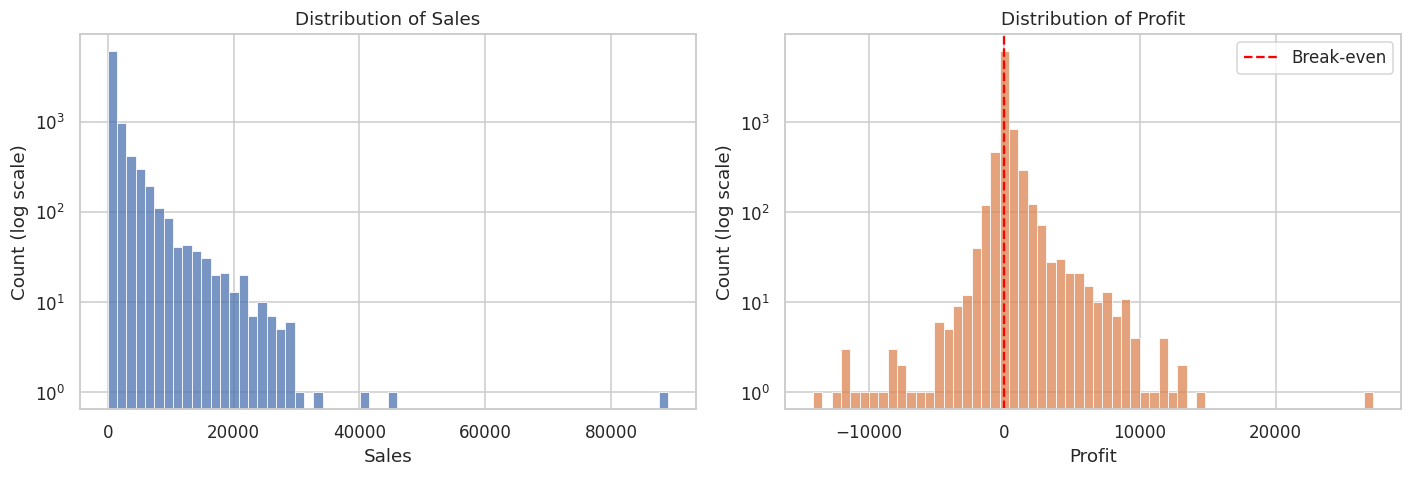

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["Sales"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("Distribution of Sales")
axes[0].set_yscale("log")
axes[0].set_ylabel("Count (log scale)")

sns.histplot(df["Profit"], bins=60, ax=axes[1], color="#DD8452")
axes[1].set_title("Distribution of Profit")
axes[1].set_yscale("log")
axes[1].set_ylabel("Count (log scale)")
axes[1].axvline(0, color="red", linestyle="--", label="Break-even")
axes[1].legend()

plt.tight_layout()
plt.savefig("screenshots/03_sales_profit_distribution.png", bbox_inches="tight")
plt.show()

### Observation
Both distributions are sharply peaked near zero with long tails (a log scale is used on the y-axis
so the tails stay visible). Sales has a long right tail of a few very large orders. Profit is
centred around break-even with tails on **both** sides, confirming that big wins and big losses are
both happening.

## 9. Bivariate Analysis: Sales and Profit Across Business Segments

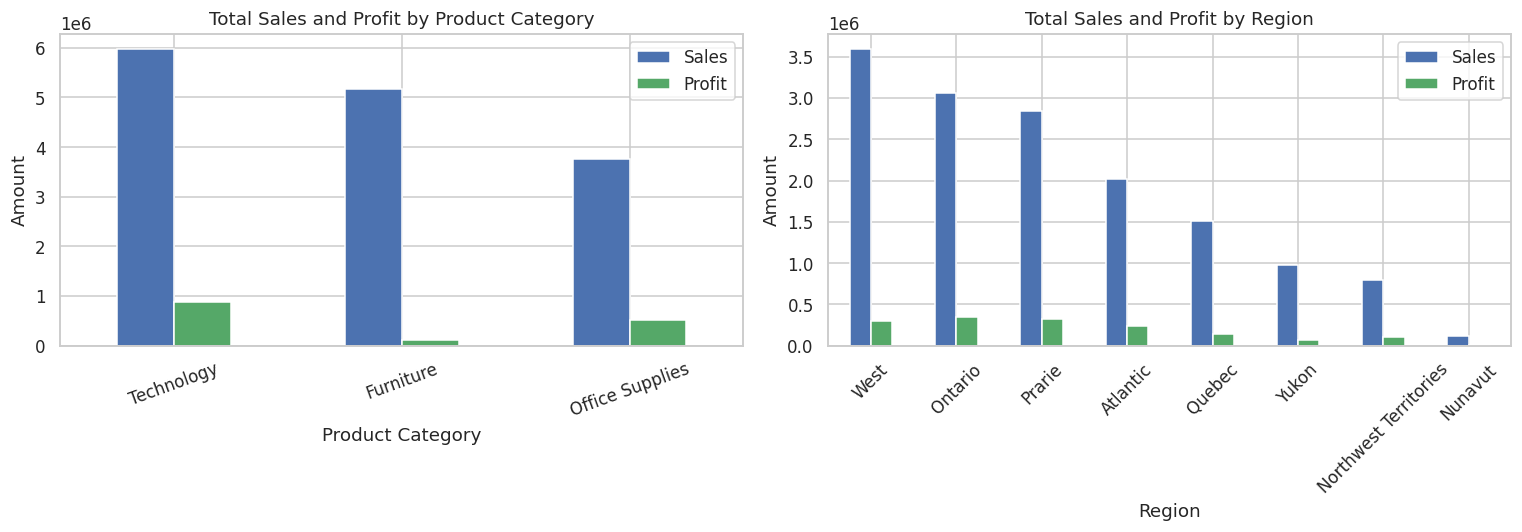

                      Sales    Profit
Product Category                     
Technology        5984248.0  886314.0
Furniture         5178591.0  117433.0
Office Supplies   3752762.0  518021.0

                           Sales    Profit
Region                                    
West                   3597549.0  297009.0
Ontario                3063212.0  346869.0
Prarie                 2837305.0  321160.0
Atlantic               2014248.0  238961.0
Quebec                 1510195.0  140427.0
Yukon                   975867.0   73849.0
Northwest Territories   800847.0  100653.0
Nunavut                 116376.0    2841.0


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat = df.groupby("Product Category")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
cat.plot(kind="bar", ax=axes[0], color=["#4C72B0", "#55A868"])
axes[0].set_title("Total Sales and Profit by Product Category")
axes[0].set_ylabel("Amount")
axes[0].tick_params(axis="x", rotation=20)

reg = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)
reg.plot(kind="bar", ax=axes[1], color=["#4C72B0", "#55A868"])
axes[1].set_title("Total Sales and Profit by Region")
axes[1].set_ylabel("Amount")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("screenshots/04_sales_profit_by_category_region.png", bbox_inches="tight")
plt.show()

print(cat.round(0))
print()
print(reg.round(0))

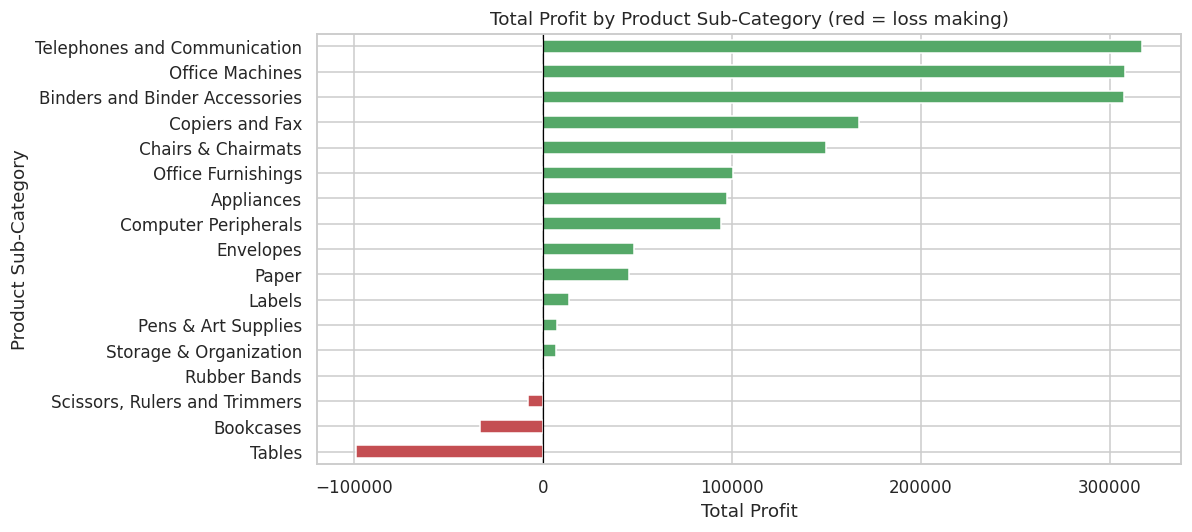

Loss-making sub-categories:
Product Sub-Category
Tables                          -99062.0
Bookcases                       -33582.0
Scissors, Rulers and Trimmers    -7799.0
Rubber Bands                      -103.0
Name: Profit, dtype: float64


In [18]:
plt.figure(figsize=(11, 5))
sub = df.groupby("Product Sub-Category")["Profit"].sum().sort_values()
colors = ["#C44E52" if v < 0 else "#55A868" for v in sub.values]
sub.plot(kind="barh", color=colors)
plt.title("Total Profit by Product Sub-Category (red = loss making)")
plt.xlabel("Total Profit")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("screenshots/05_profit_by_subcategory.png", bbox_inches="tight")
plt.show()

print("Loss-making sub-categories:")
print(sub[sub < 0].round(0))

### Observation
- **Technology brings in the most profit** even though Office Supplies has the most order lines.
- Profit is **not** spread evenly across sub-categories. A handful of sub-categories lose money
  overall, and Tables is the worst offender by a wide margin.
- Some regions sell a lot but return comparatively little profit, which points to discounting or
  shipping cost rather than to weak demand.

## 10. Effect of Discount on Profit

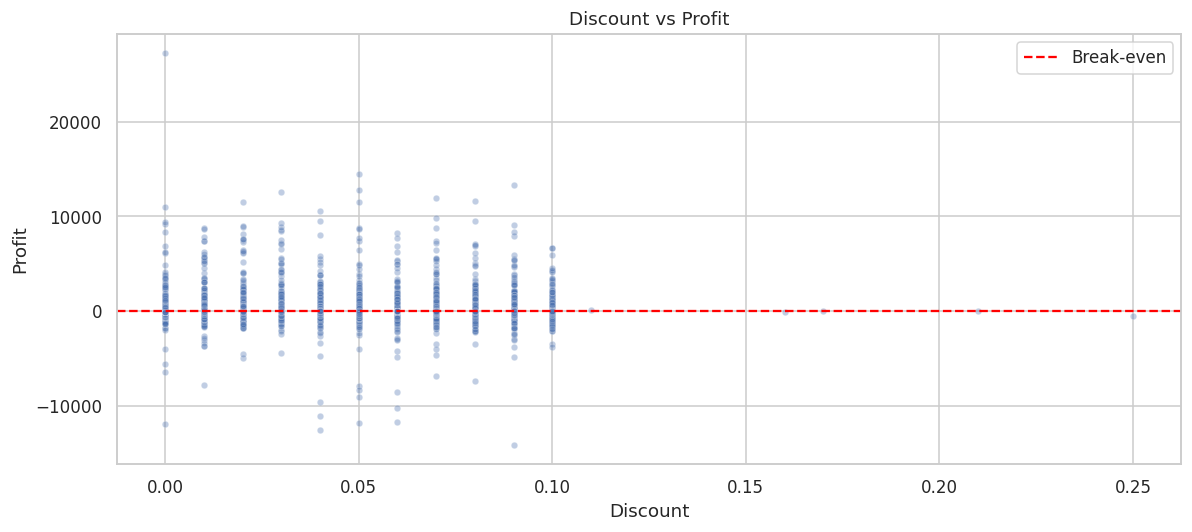

,Orders,Avg_Profit,Loss_Rate
Discount,,,
"(-0.001, 0.02]",2327,230.724,0.472
"(0.02, 0.05]",2335,205.344,0.488
"(0.05, 0.08]",2209,143.652,0.530
"(0.08, 0.11]",1524,123.786,0.560
"(0.11, 0.25]",4,-145.608,1.000


In [19]:
plt.figure(figsize=(11, 5))
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.35, s=18, color="#4C72B0")
plt.axhline(0, color="red", linestyle="--", label="Break-even")
plt.title("Discount vs Profit")
plt.legend()
plt.tight_layout()
plt.savefig("screenshots/06_discount_vs_profit.png", bbox_inches="tight")
plt.show()

bands = pd.cut(df["Discount"], bins=[-0.001, 0.02, 0.05, 0.08, 0.11, 0.25])
disc = df.groupby(bands, observed=False).agg(
    Orders=("Profit", "size"),
    Avg_Profit=("Profit", "mean"),
    Loss_Rate=("Profit", lambda s: (s < 0).mean())
).round(3)
disc

### Observation
Average profit **falls as the discount band rises**, and the share of loss-making orders climbs
with it. Discounting is a direct lever on profitability in this business, not a neutral marketing
cost.

## 11. Correlation Analysis

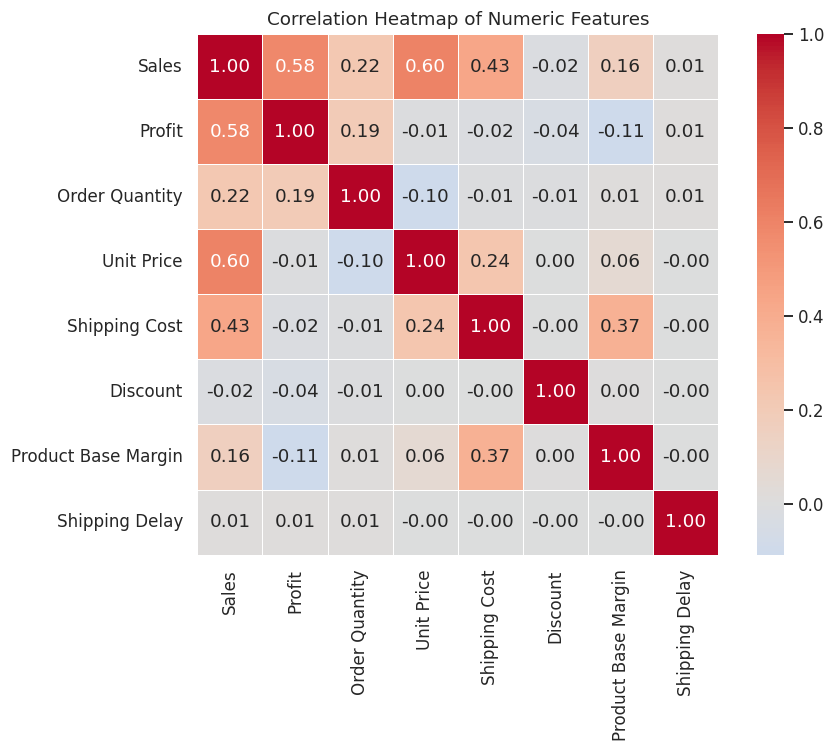

Strongest correlations with Sales:
Unit Price             0.603
Profit                 0.582
Shipping Cost          0.435
Order Quantity         0.221
Product Base Margin    0.159
Shipping Delay         0.011
Discount              -0.020
Name: Sales, dtype: float64


In [20]:
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.savefig("screenshots/07_correlation_heatmap.png", bbox_inches="tight")
plt.show()

print("Strongest correlations with Sales:")
print(corr["Sales"].drop("Sales").sort_values(ascending=False).round(3))

### Observation
- **`Sales` and `Unit Price` and `Shipping Cost` move together** most strongly: expensive items
  produce bigger sale values and cost more to ship.
- `Profit` has only a moderate correlation with `Sales`, which is important. A big sale does not
  automatically mean a big profit.
- `Discount` shows a weak **negative** correlation with profit, matching what the scatter plot
  showed.
- No pair of features is near-perfectly correlated, so there is no redundant column to drop.

## 12. Time Trend: Monthly Sales

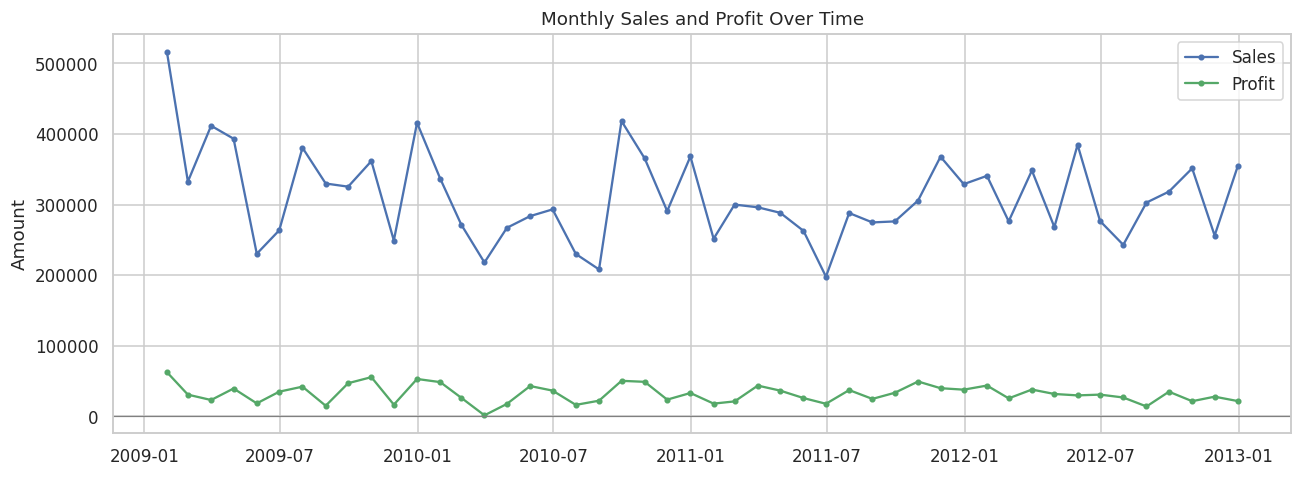

Yearly totals:
                Sales    Profit
Order Date                     
2009        4209139.0  434539.0
2010        3549681.0  363871.0
2011        3436817.0  381456.0
2012        3719964.0  341902.0


In [21]:
monthly = df.set_index("Order Date").resample("ME")[["Sales", "Profit"]].sum()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly["Sales"], marker="o", markersize=3,
        label="Sales", color="#4C72B0")
ax.plot(monthly.index, monthly["Profit"], marker="o", markersize=3,
        label="Profit", color="#55A868")
ax.axhline(0, color="grey", linewidth=0.8)
ax.set_title("Monthly Sales and Profit Over Time")
ax.set_ylabel("Amount")
ax.legend()
plt.tight_layout()
plt.savefig("screenshots/08_monthly_sales_trend.png", bbox_inches="tight")
plt.show()

print("Yearly totals:")
print(df.groupby(df["Order Date"].dt.year)[["Sales", "Profit"]].sum().round(0))

### Observation
Monthly sales are **volatile with no clean seasonal pattern**, and profit stays close to the zero
line all the way through even in high-sales months. That gap between the two lines is the clearest
visual statement of the core problem: revenue is healthy, margin is not.

## 13. Summary of Key Findings

1. **The data was almost clean.** Only `Product Base Margin` had gaps (63 values, 0.75%), filled
   with the category median. No duplicate rows and no invalid dates, quantities or sales.
2. **Money columns are heavily skewed and full of outliers**, which were kept on purpose because
   large orders and large losses are real business events, not errors.
3. **Roughly half of all order lines lose money.** This is the headline finding.
4. **Technology is the most profitable category**; Office Supplies has the most volume but thinner
   returns, and several sub-categories (Tables worst of all) lose money overall.
5. **Discount is directly tied to profitability.** Higher discount bands show lower average profit
   and a higher share of loss-making orders.
6. **Sales does not predict profit well.** They correlate only moderately, so revenue targets alone
   are a poor measure of business health.
7. **Sales and profit are volatile month to month** with no strong seasonality, and profit hovers
   near break-even across the whole period.

### Key Lessons and Improvements for the Next Iteration
- Filling missing margins with a category median is quick but crude. A better version would look at
  the sub-category or the specific product before filling.
- Outliers were kept, which is the right call for a business report, but a modelling task would
  benefit from also testing a capped or log-transformed version of `Sales`.
- This analysis works at the order-line level. Rolling it up to whole orders or to customers would
  answer different and equally useful questions, such as which customers are unprofitable overall.
- The dataset has no cost-of-goods column, so the reason behind each loss can only be inferred from
  discount and shipping cost. Adding cost data would make the profit analysis conclusive.
- The next step follows naturally from finding 3: build a model that predicts **whether an order
  will be profitable**, which is exactly what Task 2 does.